
# Hybrid distillation from PPO ensemble 

- Uses your CNet192 + ActorCritic definitions.
- Loads PPO teacher checkpoints.
- Builds an ensemble teacher, weighted by metascores.
- Collects an offline dataset via simple self-play.
- Trains a new student ActorCritic to imitate the ensemble policy.
- Saves the distilled student checkpoint for later PPO finetuning.



In [1]:
import math
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple
from tqdm.auto import tqdm
from tqdm.auto import trange
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from C4.CNet192 import save_cnet192
from C4.fast_connect4_lookahead import Connect4Lookahead

from PPO.actor_critic import ActorCritic, TransferCfg, NEG_INF  # uses C4.CNet192 under the hood
from C4.connect4_env import Connect4Env

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 1. Config: ensemble teachers and metascores

In [2]:
NEW = "DIST_III"
FREEZE = True

In [3]:
HOF_METASCORES = {
    "PPO_Models/PPO_713.pt": 0.840,
    "PPO_Models/PPO_712.pt": 0.649,
    "PPO_Models/PPO_714.pt": 0.599,
    "PPO_Models/PPO_709.pt": 0.548,
    "PPO_Models/PPO_708.pt": 0.548,
    "PPO_Models/PPO_706.pt": 0.454,
    "PPO_Models/PPO_710.pt": 0.453,
    "PPO_Models/PPO_707.pt": 0.450,
    "PPO_Models/PPO_705.pt": 0.402,
    "PPO_Models/PPO_703.pt": 0.303,
    "PPO_Models/PPO_704.pt": 0.256,
}


In [4]:
def make_env() -> Connect4Env:
    """Factory to keep the rest of the notebook agnostic."""
    return Connect4Env()

def metas_to_weights(metas: Dict[str, float]) -> Dict[str, float]:
    keys = list(metas.keys())
    vals = np.array([metas[k] for k in keys], dtype=np.float64)
    w = vals / vals.sum()
    return {k: float(w[i]) for i, k in enumerate(keys)}

ENSEMBLE_WEIGHTS = metas_to_weights(HOF_METASCORES)
print("Ensemble weights:")
for path, w in ENSEMBLE_WEIGHTS.items():
    print(f"  {path}: {w:.3f}")

Ensemble weights:
  PPO_Models/PPO_713.pt: 0.153
  PPO_Models/PPO_712.pt: 0.118
  PPO_Models/PPO_714.pt: 0.109
  PPO_Models/PPO_709.pt: 0.100
  PPO_Models/PPO_708.pt: 0.100
  PPO_Models/PPO_706.pt: 0.083
  PPO_Models/PPO_710.pt: 0.082
  PPO_Models/PPO_707.pt: 0.082
  PPO_Models/PPO_705.pt: 0.073
  PPO_Models/PPO_703.pt: 0.055
  PPO_Models/PPO_704.pt: 0.047


## 2. Load PPO ActorCritic teachers from checkpoints

In [5]:
def load_actor_critic_from_ckpt(
    path: str | Path,
    device: torch.device,
) -> ActorCritic:
    """
    Load PPO teacher from a CNet192-style checkpoint
    Uses ActorCritic.from_cnet192_checkpoint so that conv weights land in ac.net.*.
    """
    path = Path(path)

    # Use the helper that knows about CNet192 checkpoints
    ac = ActorCritic.from_cnet192_checkpoint(
        path=str(path),
        device=device,
        transfer=TransferCfg(
            strict_load=True,   # they *should* match exactly
            freeze_conv=FREEZE,   # freeze or False if you want to finetune in union
        ),
    )

    # Just sanity: nothing should be missing now
    # (state_dict is already loaded inside from_cnet192_checkpoint)
    ac.eval()
    for p in ac.parameters():
        p.requires_grad_(False)

    print(f"Loaded {path.name} via from_cnet192_checkpoint (conv frozen={True})")
    return ac

teacher_paths = list(HOF_METASCORES.keys()) 
teachers: List[ActorCritic] = [load_actor_critic_from_ckpt(p, device) for p in teacher_paths] 
teacher_weights = np.array([ENSEMBLE_WEIGHTS[p] for p in teacher_paths], dtype=np.float32) 
teacher_weights = teacher_weights / teacher_weights.sum()


Loaded PPO_713.pt via from_cnet192_checkpoint (conv frozen=True)
Loaded PPO_712.pt via from_cnet192_checkpoint (conv frozen=True)
Loaded PPO_714.pt via from_cnet192_checkpoint (conv frozen=True)
Loaded PPO_709.pt via from_cnet192_checkpoint (conv frozen=True)
Loaded PPO_708.pt via from_cnet192_checkpoint (conv frozen=True)
Loaded PPO_706.pt via from_cnet192_checkpoint (conv frozen=True)
Loaded PPO_710.pt via from_cnet192_checkpoint (conv frozen=True)
Loaded PPO_707.pt via from_cnet192_checkpoint (conv frozen=True)
Loaded PPO_705.pt via from_cnet192_checkpoint (conv frozen=True)
Loaded PPO_703.pt via from_cnet192_checkpoint (conv frozen=True)
Loaded PPO_704.pt via from_cnet192_checkpoint (conv frozen=True)


## 3. Optional POP / bitboard teacher hook

In [6]:
# --- Real POP / lookahead teacher -------------------------------------------

class PopLookaheadTeacher:
    """
    Bitboard lookahead teacher using your Connect4Lookahead.

    Expects:
      - board_pov: np.ndarray with values in {-1, 0, +1}, shape (6,7) or (1,6,7)
        POV: current player stones = +1, opponent = -1
      - legal_actions: list of legal columns

    We always call the lookahead as "player 1" on that POV board.
    """

    def __init__(self, depth: int = 9, temperature: float = 0.05):
        self.la = Connect4Lookahead()
        # deterministic, no random opening for distillation
        self.la.OPENING_RANDOM = False
        self.depth = int(depth)
        self.temperature = float(temperature)

    def _normalize_board(self, board_pov: np.ndarray) -> np.ndarray:
        b = np.asarray(board_pov, dtype=np.int8)
        if b.ndim == 3:
            # (1,6,7) or (B,6,7) – for teacher we only ever pass a single state
            if b.shape[0] == 1:
                b = b[0]
            else:
                raise ValueError(f"PopLookaheadTeacher: unexpected 3D shape {b.shape}")
        if b.ndim != 2 or b.shape != (6, 7):
            raise ValueError(f"PopLookaheadTeacher: expected (6,7) POV board, got {b.shape}")
        return b

    def policy(self, board_pov: np.ndarray, legal_actions: List[int]) -> np.ndarray:
        probs = np.zeros(7, dtype=np.float32)
        if not legal_actions:
            return probs

        board = self._normalize_board(board_pov)

        # full negamax action scores at fixed depth
        scores = self.la.n_step_action_scores(board, player=1, depth=self.depth)  # shape (7,)

        # mask illegal moves
        mask = np.zeros(7, dtype=bool)
        mask[legal_actions] = True
        scores_masked = scores.copy()
        scores_masked[~mask] = -1e9  # effectively -inf

        # softmax with small temperature (near-greedy)
        s = scores_masked.astype(np.float64)
        # stability: only use legal subset for max
        s_legal = s[mask]
        if s_legal.size == 0:
            probs[legal_actions] = 1.0 / len(legal_actions)
            return probs

        T = max(self.temperature, 1e-6)
        s = s - np.max(s_legal)
        p = np.exp(s / T)
        p[~mask] = 0.0

        Z = p.sum()
        if Z <= 0.0:
            # fallback: uniform over legal
            probs[legal_actions] = 1.0 / len(legal_actions)
            return probs

        p /= Z
        probs[:] = p.astype(np.float32)
        return probs


# plug this into the hybrid teacher config
POP_TEACHER = PopLookaheadTeacher(depth=9, temperature=0.05)  # tune as you like
POP_WEIGHT = 0.0  # start at 0.0, turn up when you actually want POP mixed in


In [7]:
POP_TEACHER = PopLookaheadTeacher(depth=9, temperature=0.75)  # tweak depth / temp as you like
POP_WEIGHT  = 0.30  # e.g. 30% of total teacher mass from POP, 70% from PPO ensemble

## 4. Teacher ensemble policy

In [8]:
class HybridTeacherEnsemble:
    """
    Combines:
      - PPO ActorCritic teachers (ensemble, meta-weighted)
      - optional POP teacher (bitboard lookahead) with POP_WEIGHT
    """

    def __init__(
        self,
        teachers: List[ActorCritic],
        teacher_weights: np.ndarray,
        pop_teacher: Optional[PopLookaheadTeacher] = None,
        pop_weight: float = 0.0,
        device: Optional[torch.device] = None,
    ):
        assert len(teachers) == len(teacher_weights)
        self.teachers = teachers
        self.tw = np.asarray(teacher_weights, dtype=np.float32)
        self.tw /= self.tw.sum()
        self.pop_teacher = pop_teacher
        self.pop_weight = float(pop_weight)
        self.device = device or torch.device("cpu")

    @torch.no_grad()
    def ppo_ensemble_policy(
        self,
        board_pov: np.ndarray,
        legal_actions: List[int],
    ) -> np.ndarray:
        """Meta-weighted average of all PPO teachers (legal-only distribution)."""
        probs_out = np.zeros(7, dtype=np.float32)
        if not legal_actions:
            return probs_out

        # legal mask on the same device as models
        mask = torch.zeros(1, 7, dtype=torch.bool, device=self.device)
        mask[0, legal_actions] = True

        # state as (1,6,7) float32
        x = torch.as_tensor(board_pov, dtype=torch.float32, device=self.device)
        if x.dim() == 2:
            x = x.unsqueeze(0)  # (1,6,7)

        probs_list = []
        for t in self.teachers:
            logits, _ = t(x)  # (1,7)
            if logits.dim() == 1:
                logits = logits.unsqueeze(0)
            masked_logits = logits.masked_fill(~mask, NEG_INF)
            p = torch.softmax(masked_logits, dim=-1)[0].cpu().numpy().astype(np.float32)
            probs_list.append(p)

        probs_stack = np.stack(probs_list, axis=0)  # (T,7)
        mix = (self.tw[:, None] * probs_stack).sum(axis=0)  # (7,)

        # re-normalize on legal only
        probs_out[legal_actions] = mix[legal_actions]
        s = float(probs_out[legal_actions].sum())
        if s <= 1e-12:
            probs_out[legal_actions] = 1.0 / len(legal_actions)
        else:
            probs_out /= s
        return probs_out

    def policy(
        self,
        board_pov: np.ndarray,
        legal_actions: List[int],
    ) -> np.ndarray:
        """
        Final hybrid policy:
            pi = (1 - POP_WEIGHT) * PPO_ensemble + POP_WEIGHT * POP_teacher
        Always normalized over *legal* actions only.
        """
        probs_zero = np.zeros(7, dtype=np.float32)
        if not legal_actions:
            return probs_zero

        p_ppo = self.ppo_ensemble_policy(board_pov, legal_actions)

        # No POP teacher or disabled -> just PPO ensemble
        if self.pop_teacher is None or self.pop_weight <= 0.0:
            return p_ppo

        # POP teacher distribution (should already be legal-only, but we sanitize anyway)
        p_pop = self.pop_teacher.policy(board_pov, legal_actions).astype(np.float32)
        p_pop = np.clip(p_pop, 0.0, 1.0)
        s_pop = float(p_pop.sum())
        if s_pop <= 0.0:
            p_pop[:] = 0.0
            p_pop[legal_actions] = 1.0 / len(legal_actions)
        else:
            p_pop /= s_pop

        w = float(self.pop_weight)

        # mix only on legal actions, keep illegal exactly 0
        mix_raw = (1.0 - w) * p_ppo + w * p_pop
        mix = np.zeros(7, dtype=np.float32)
        mix[legal_actions] = mix_raw[legal_actions]

        s = float(mix[legal_actions].sum())
        if s <= 1e-12:
            mix[legal_actions] = 1.0 / len(legal_actions)
        else:
            mix /= s

        return mix.astype(np.float32)


hybrid_teacher = HybridTeacherEnsemble(
    teachers=teachers,
    teacher_weights=teacher_weights,
    pop_teacher=POP_TEACHER,
    pop_weight=POP_WEIGHT,
    device=device,
)


## 6. Collect hybrid-teacher dataset

In [9]:
@dataclass
class DistillCollectCfg:
    num_games: int = 2000
    max_moves: int = 42  # full board
    random_seed: int = 666


def collect_distill_data(
    teacher: HybridTeacherEnsemble,
    cfg: DistillCollectCfg,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    rng = np.random.default_rng(cfg.random_seed)
    env = make_env()

    states: List[np.ndarray] = []
    legal_masks: List[np.ndarray] = []
    teacher_probs: List[np.ndarray] = []

    # tqdm on games
    for g in tqdm(range(cfg.num_games), desc="Collecting distill data"):
        s = env.reset()  # (1, 6, 7) from env.get_state
        for t in range(cfg.max_moves):
            legal = env.available_actions()
            if not legal:
                break

            # Teacher policy over all 7 actions
            pi = teacher.policy(s, legal)     # shape (7,)
            a = int(rng.choice(7, p=pi))

            # Record (state POV, legal mask, teacher policy)
            mask = np.zeros(7, dtype=bool)
            mask[legal] = True

            states.append(s.astype(np.float32))         # (1, 6, 7)
            legal_masks.append(mask)                    # (7,)
            teacher_probs.append(pi.astype(np.float32)) # (7,)

            s, rew, done = env.step(a)
            if done:
                break

    states_arr = np.stack(states, axis=0)          # (N, 1, 6, 7)
    legal_arr  = np.stack(legal_masks, axis=0)     # (N, 7) bool
    teacher_arr = np.stack(teacher_probs, axis=0)  # (N, 7)

    print(f"Collected {states_arr.shape[0]} samples from {cfg.num_games} games.")
    return states_arr, legal_arr, teacher_arr


# Example usage
collect_cfg = DistillCollectCfg(num_games=1000, max_moves=42, random_seed=666)
states_arr, legal_arr, teacher_arr = collect_distill_data(hybrid_teacher, collect_cfg)

Collected 25160 samples from 1000 games.


## 7. Distillation dataset and DataLoader

In [10]:
class DistillDataset(Dataset):
    def __init__(
        self,
        states: np.ndarray,
        legal_masks: np.ndarray,
        teacher_probs: np.ndarray,
    ):
        assert states.shape[0] == legal_masks.shape[0] == teacher_probs.shape[0]
        self.states = torch.as_tensor(states, dtype=torch.float32)
        self.legal_masks = torch.as_tensor(legal_masks, dtype=torch.bool)
        self.teacher_probs = torch.as_tensor(teacher_probs, dtype=torch.float32)

    def __len__(self) -> int:
        return self.states.shape[0]

    def __getitem__(self, idx: int):
        return (
            self.states[idx],       # (6,7)
            self.legal_masks[idx],  # (7,)
            self.teacher_probs[idx] # (7,)
        )


batch_size = 512
dataset = DistillDataset(states_arr, legal_arr, teacher_arr)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=False)
print("Dataset size:", len(dataset))

Dataset size: 25160


## 8. Student ActorCritic and distillation loss
We train:

\[
L = -\mathbb{E}_{s} \sum_a \pi_{\text{teacher}}(a|s)\,\log \pi_{\text{student}}(a|s)
\]

(pure policy distillation; critic head is left free and will be trained later by PPO).

In [11]:
student = ActorCritic(use_mid_3x3=True).to(device)
print("Student parameters:", sum(p.numel() for p in student.parameters()))

optimizer = torch.optim.Adam(student.parameters(), lr=3e-4, weight_decay=1e-5)
grad_clip = 1.0
num_epochs = 100


def distill_epoch(epoch_idx: int, num_epochs: int) -> float:
    student.train()
    total_loss = 0.0
    total_samples = 0

    for states, legal_masks, teacher_probs in loader:
        states = states.to(device)           # (B, 1, 6, 7) or (B, 6, 7) depending on loader
        legal_masks = legal_masks.to(device) # (B, 7) bool
        targets = teacher_probs.to(device)   # (B, 7) float

        logits, _ = student(states)          # (B, 7)
        masked_logits = logits.masked_fill(~legal_masks, NEG_INF)
        log_probs = torch.log_softmax(masked_logits, dim=-1)  # (B, 7)

        # Cross-entropy w.r.t. soft targets
        loss = -(targets * log_probs).sum(dim=-1).mean()

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(student.parameters(), grad_clip)
        optimizer.step()

        B = states.size(0)
        total_loss += float(loss.item()) * B
        total_samples += B

        avg_loss = total_loss / max(1, total_samples)

    avg_loss = total_loss / max(1, total_samples)
    print(f"Epoch {epoch_idx:02d} | distill loss: {avg_loss:.5f}")
    return avg_loss

loss_history = []
for ep in trange(1, num_epochs + 1, desc="Distill epochs"):
    avg_loss = distill_epoch(ep, num_epochs)
    loss_history.append(avg_loss)


Student parameters: 779912


Distill epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 01 | distill loss: 1.65868
Epoch 02 | distill loss: 1.49837
Epoch 03 | distill loss: 1.40366
Epoch 04 | distill loss: 1.31364
Epoch 05 | distill loss: 1.24713
Epoch 06 | distill loss: 1.18489
Epoch 07 | distill loss: 1.14019
Epoch 08 | distill loss: 1.09688
Epoch 09 | distill loss: 1.05968
Epoch 10 | distill loss: 1.02773
Epoch 11 | distill loss: 1.00019
Epoch 12 | distill loss: 0.97678
Epoch 13 | distill loss: 0.95904
Epoch 14 | distill loss: 0.93754
Epoch 15 | distill loss: 0.91666
Epoch 16 | distill loss: 0.90130
Epoch 17 | distill loss: 0.88843
Epoch 18 | distill loss: 0.87081
Epoch 19 | distill loss: 0.85777
Epoch 20 | distill loss: 0.84657
Epoch 21 | distill loss: 0.83687
Epoch 22 | distill loss: 0.82633
Epoch 23 | distill loss: 0.81503
Epoch 24 | distill loss: 0.80408
Epoch 25 | distill loss: 0.79635
Epoch 26 | distill loss: 0.78615
Epoch 27 | distill loss: 0.78506
Epoch 28 | distill loss: 0.77516
Epoch 29 | distill loss: 0.76764
Epoch 30 | distill loss: 0.76214
Epoch 31 |

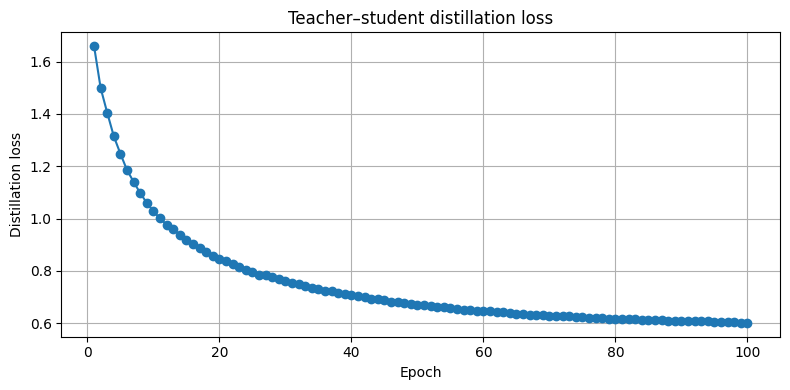

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Distillation loss")
plt.title("Teacher–student distillation loss")
plt.grid(True)
plt.tight_layout()
plt.show()


## 9. Quick sanity check vs teachers on a few random states

In [13]:
@torch.no_grad()
def compare_student_to_teacher(num_samples: int = 5):
    student.eval()
    env = make_env()
    rng = np.random.default_rng(999)

    for i in range(num_samples):
        s = env.reset()
        # random number of warmup moves by teacher ensemble
        for t in range(rng.integers(0, 15)):
            legal = env.available_actions()
            if not legal:
                break
            pi_t = hybrid_teacher.policy(s, legal)
            a = int(rng.choice(7, p=pi_t))
            s, rew, done = env.step(a)
            if done:
                s = env.reset()

        legal = env.available_actions()
        if not legal:
            continue

        # Teacher
        pi_teacher = hybrid_teacher.policy(s, legal)

        # Student
        x = torch.as_tensor(s, dtype=torch.float32, device=device)
        if x.dim() == 2:
            x = x.unsqueeze(0)
        logits, _ = student(x)
        mask = torch.zeros_like(logits, dtype=torch.bool)
        mask[0, legal] = True
        masked_logits = logits.masked_fill(~mask, NEG_INF)
        pi_student = torch.softmax(masked_logits, dim=-1)[0].cpu().numpy()

        print(f"\nSample {i+1}")
        print("Legal:", legal)
        print("Teacher:", np.round(pi_teacher, 3))
        print("Student:", np.round(pi_student, 3))

compare_student_to_teacher(num_samples=5)


Sample 1
Legal: [0, 1, 2, 3, 4, 5, 6]
Teacher: [0.    0.    0.299 0.012 0.    0.11  0.579]
Student: [0.    0.    0.225 0.014 0.001 0.04  0.719]

Sample 2
Legal: [0, 1, 2, 3, 4, 5, 6]
Teacher: [0.    0.307 0.    0.    0.    0.693 0.   ]
Student: [0.    0.485 0.    0.    0.01  0.504 0.   ]

Sample 3
Legal: [0, 1, 2, 3, 4, 5, 6]
Teacher: [0.  0.  0.3 0.  0.7 0.  0. ]
Student: [0.005 0.001 0.19  0.001 0.794 0.001 0.008]

Sample 4
Legal: [0, 1, 2, 3, 4, 5, 6]
Teacher: [0.    0.485 0.    0.    0.    0.515 0.   ]
Student: [0.    0.489 0.    0.    0.    0.511 0.   ]

Sample 5
Legal: [0, 1, 2, 3, 4, 5, 6]
Teacher: [0.001 0.047 0.    0.9   0.049 0.003 0.   ]
Student: [0.001 0.03  0.    0.944 0.022 0.002 0.   ]


## 10. Save distilled student checkpoint

In [14]:
out_path = Path(f"PPO_Models/{NEW}.pt")
save_cnet192(
    model=student.net,          # <<< only the CNet192 inside ActorCritic
    path=out_path,
    tag=NEW,
    session=NEW,
    episode=0,
    seed=0,
    t=0,
    cfg_override={"use_mid_3x3": True},  # optional, if you want it in cfg
)

print("Saved distilled PPO student to:", out_path)

Saved distilled PPO student to: PPO_Models\DIST_III.pt
